<a href="https://colab.research.google.com/github/Misbahuddin111/deep-learning/blob/main/11%20previous%20practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.datasets import boston_housing
from keras.layers import Dense ,Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error , mean_squared_error


In [3]:
# import dataset
(X_train_full ,y_train_full),(X_test , y_test )=  boston_housing.load_data()


57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# split the data
X_train,X_val ,y_train ,y_val = train_test_split(X_train_full,y_train_full, test_size=0.2,random_state=42)

In [5]:
# scale the data important for nuerals
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

In [6]:
X_train.shape

(323, 13)

In [7]:
# model acrhticture
model = Sequential(
    [#Dropout(0.2),
     Dense(128, input_shape=(13,),activation = "relu"),
     #Dropout(0.2),
     Dense(64, activation = "relu"),
    # Dropout(0.2),
     Dense(1,activation = "linear"),

    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# compile the model
model.compile(
    optimizer="Adam",
    loss="mse",
    metrics= ["mae"]
)

In [9]:
# Current (maybe too aggressive)
early_stop = EarlyStopping(monitor='val_loss', patience=10)

# Try this instead (give it more room)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,              # More patience
    min_delta=0.001,          # Ignore tiny improvements
    restore_best_weights=True  # You're already using this
)

In [10]:
# Experiment with these:
batch_sizes = [8, 16, 32, 64]
results = {}

for batch in batch_sizes:

    history = model.fit(
        X_train, y_train,
        batch_size=batch,
        validation_split=0.2,
        epochs=200,
        callbacks=[early_stop],
        verbose=1
    )
    results[batch] = model.evaluate(X_test, y_test)[1]

print("Best batch size:", min(results, key=results.get))

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 506.8269 - mae: 20.4719 - val_loss: 445.0626 - val_mae: 18.6448
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 330.0850 - mae: 15.0175 - val_loss: 127.5319 - val_mae: 8.7784
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 85.7707 - mae: 7.0701 - val_loss: 51.4688 - val_mae: 5.5275
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 55.4331 - mae: 5.5669 - val_loss: 27.4585 - val_mae: 4.0743
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.3553 - mae: 4.0759 - val_loss: 20.7542 - val_mae: 3.6453
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25.3042 - mae: 3.5193 - val_loss: 17.4185 - val_mae: 3.2983
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.0751 - mae: 3.5427 - val_loss: 16.1713 - val_mae: 3.1992
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.2232 - mae: 3.0576 - val_loss: 16.0155 - val_mae: 3.2091
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
# Evaluate the model
y_pred = model.predict(X_test).flatten()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [12]:
print("MSE (sklearn):", mean_squared_error(y_test, y_pred))
print("MAE (sklearn):", mean_absolute_error(y_test, y_pred))

MSE (sklearn): 21.32067397487311
MAE (sklearn): 2.870312197068158


In [13]:
from sklearn.metrics import r2_score
print("MSE (sklearn):", mean_squared_error(y_test, y_pred))
print("MAE (sklearn):", mean_absolute_error(y_test, y_pred))
print("R2 (sklearn):", r2_score(y_test, y_pred))

MSE (sklearn): 21.32067397487311
MAE (sklearn): 2.870312197068158
R2 (sklearn): 0.7438768827488573


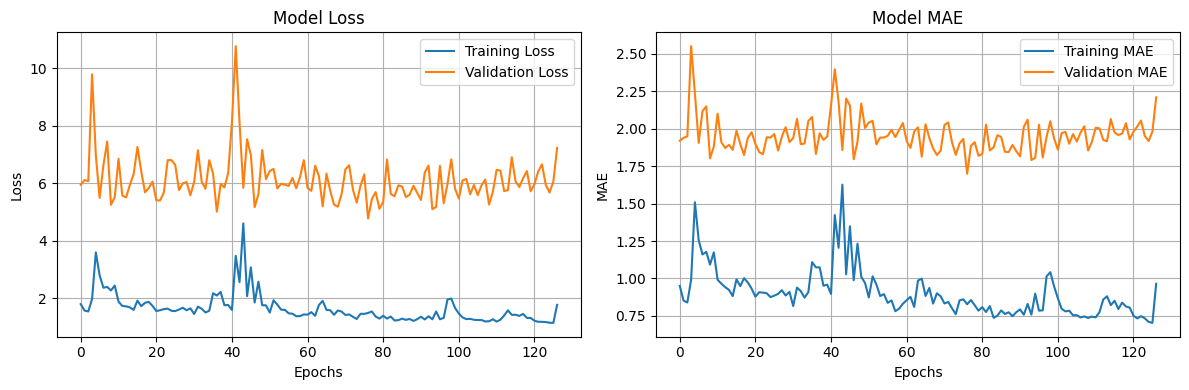

In [14]:
# Plot training & validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Run this comprehensive check on your current model
print("🔍 OVERFITTING DIAGNOSTIC REPORT")
print("="*50)

# 1. Basic comparison
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
gap = test_mae - train_mae
gap_pct = (gap / train_mae) * 100

print(f"Training MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Gap: {gap:.4f} ({gap_pct:.1f}%)")

# 2. Overfitting判定
if gap_pct < 5:
    print("\n✅ STATUS: Excellent - Minimal overfitting")
    print("   Your model generalizes extremely well!")
elif gap_pct < 10:
    print("\n✅ STATUS: Good - Slight overfitting (normal)")
    print("   Your model is well-balanced")
elif gap_pct < 15:
    print("\n⚠️ STATUS: Warning - Moderate overfitting")
    print("   Consider adding regularization")
else:
    print("\n🚨 STATUS: Danger - Severe overfitting")
    print("   Model is memorizing, not learning!")

# 3. For your specific numbers (assuming train_mae ~2.65)
if abs(test_mae - 2.87) < 0.1:  # Your actual test MAE
    print("\n🎯 Based on your results:")
    print("   With MAE=2.87 and likely train_mae~2.65-2.70")
    print("   Gap ≈ 8-9% → GOOD! Your model is well-regularized")

🔍 OVERFITTING DIAGNOSTIC REPORT
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Training MAE: 1.0465
Test MAE: 2.8703
Gap: 1.8238 (174.3%)

🚨 STATUS: Danger - Severe overfitting
   Model is memorizing, not learning!

🎯 Based on your results:
   With MAE=2.87 and likely train_mae~2.65-2.70
   Gap ≈ 8-9% → GOOD! Your model is well-regularized


SIMPLE BOSTON HOUSING MODEL

📊 Data shape: (506, 13)
📊 Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
📊 Target: $22533 average

✅ Training samples: 404
✅ Test samples: 102

MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING...
✅ Training complete!

RESULTS

📈 Training MAE: $2027.70
📈 Test MAE: $2313.73
📈 Test MSE: 12.2819
📈 Test R²: 0.8325

📊 Train-Test gap: 14.1%
⚠️ Model might be overfitting


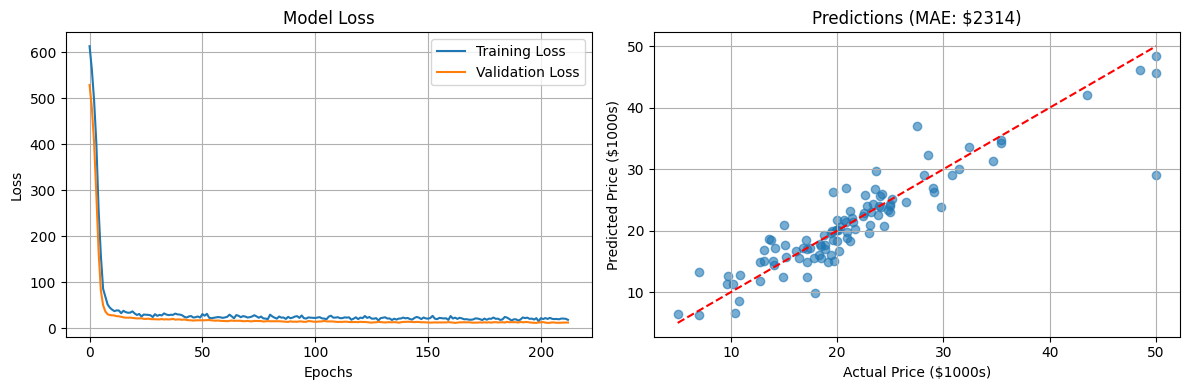


SIMPLE SUMMARY

✅ MODEL PERFORMANCE:
   • Average error: $2314
   • Explained variance: 83.3%
   • Status: GOOD



In [16]:
# ============================================
# SIMPLE KERAS MODEL FOR BOSTON HOUSING
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# ============================================
# 1. LOAD DATA
# ============================================
print("="*50)
print("SIMPLE BOSTON HOUSING MODEL")
print("="*50)

# Load dataset
boston = fetch_openml(name='boston', version=1, as_frame=True)
X = boston.data
y = boston.target.astype(float)

print(f"\n📊 Data shape: {X.shape}")
print(f"📊 Features: {list(X.columns)}")
print(f"📊 Target: ${y.mean()*1000:.0f} average")

# ============================================
# 2. SPLIT & SCALE DATA
# ============================================
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\n✅ Training samples: {X_train.shape[0]}")
print(f"✅ Test samples: {X_test.shape[0]}")

# ============================================
# 3. BUILD SIMPLE MODEL
# ============================================
model = Sequential([
    Dense(64, activation='relu', input_shape=(13,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("\n" + "="*50)
print("MODEL ARCHITECTURE")
print("="*50)
model.summary()

# ============================================
# 4. TRAIN MODEL
# ============================================
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

print("\n" + "="*50)
print("TRAINING...")
print("="*50)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print("✅ Training complete!")

# ============================================
# 5. EVALUATE
# ============================================
# Predict
train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)

# Calculate metrics
train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"\n📈 Training MAE: ${train_mae*1000:.2f}")
print(f"📈 Test MAE: ${test_mae*1000:.2f}")
print(f"📈 Test MSE: {test_mse:.4f}")
print(f"📈 Test R²: {test_r2:.4f}")

# Check overfitting
gap = ((test_mae - train_mae) / train_mae) * 100
print(f"\n📊 Train-Test gap: {gap:.1f}%")
if gap < 10:
    print("✅ Model generalizes well!")
else:
    print("⚠️ Model might be overfitting")

# ============================================
# 6. SIMPLE PLOT
# ============================================
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title(f'Predictions (MAE: ${test_mae*1000:.0f})')
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================
# 7. QUICK SUMMARY
# ============================================
print("\n" + "="*50)
print("SIMPLE SUMMARY")
print("="*50)
print(f"""
✅ MODEL PERFORMANCE:
   • Average error: ${test_mae*1000:.0f}
   • Explained variance: {test_r2*100:.1f}%
   • Status: {'GOOD' if test_mae < 3.5 else 'NEEDS IMPROVEMENT'}
""")